In [1]:
import os
import tarfile
import urllib.request
import pandas as pd

# 1. Define the URLs and local paths where data will live
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"
HOUSING_PATH = os.path.join("datasets", "housing")

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    """Downloads the compressed tarball and extracts the CSV dataset."""
    # Create the directory if it doesn't exist yet
    os.makedirs(housing_path, exist_ok=True)
    
    # Path where the compressed tgz file will temporarily sit
    tgz_path = os.path.join(housing_path, "housing.tgz")
    
    # Download the file from GitHub
    print("Downloading dataset from GitHub...")
    urllib.request.urlretrieve(housing_url, tgz_path)
    
    # Extract the tarball to expose the housing.csv file
    print("Extracting housing.tgz...")
    with tarfile.open(tgz_path) as housing_tgz:
        housing_tgz.extractall(path=housing_path)
        
    print("Data download and extraction complete!")

# Execute the download function
fetch_housing_data()

Extracting housing.tgz...
Data download and extraction complete!


In [2]:
def load_housing_data(housing_path=HOUSING_PATH):
    """Loads the extracted housing.csv file into a Pandas DataFrame."""
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

# Load the data and view the top 5 rows
housing = load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [5]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Matplotlib is building the font cache; this may take a moment.


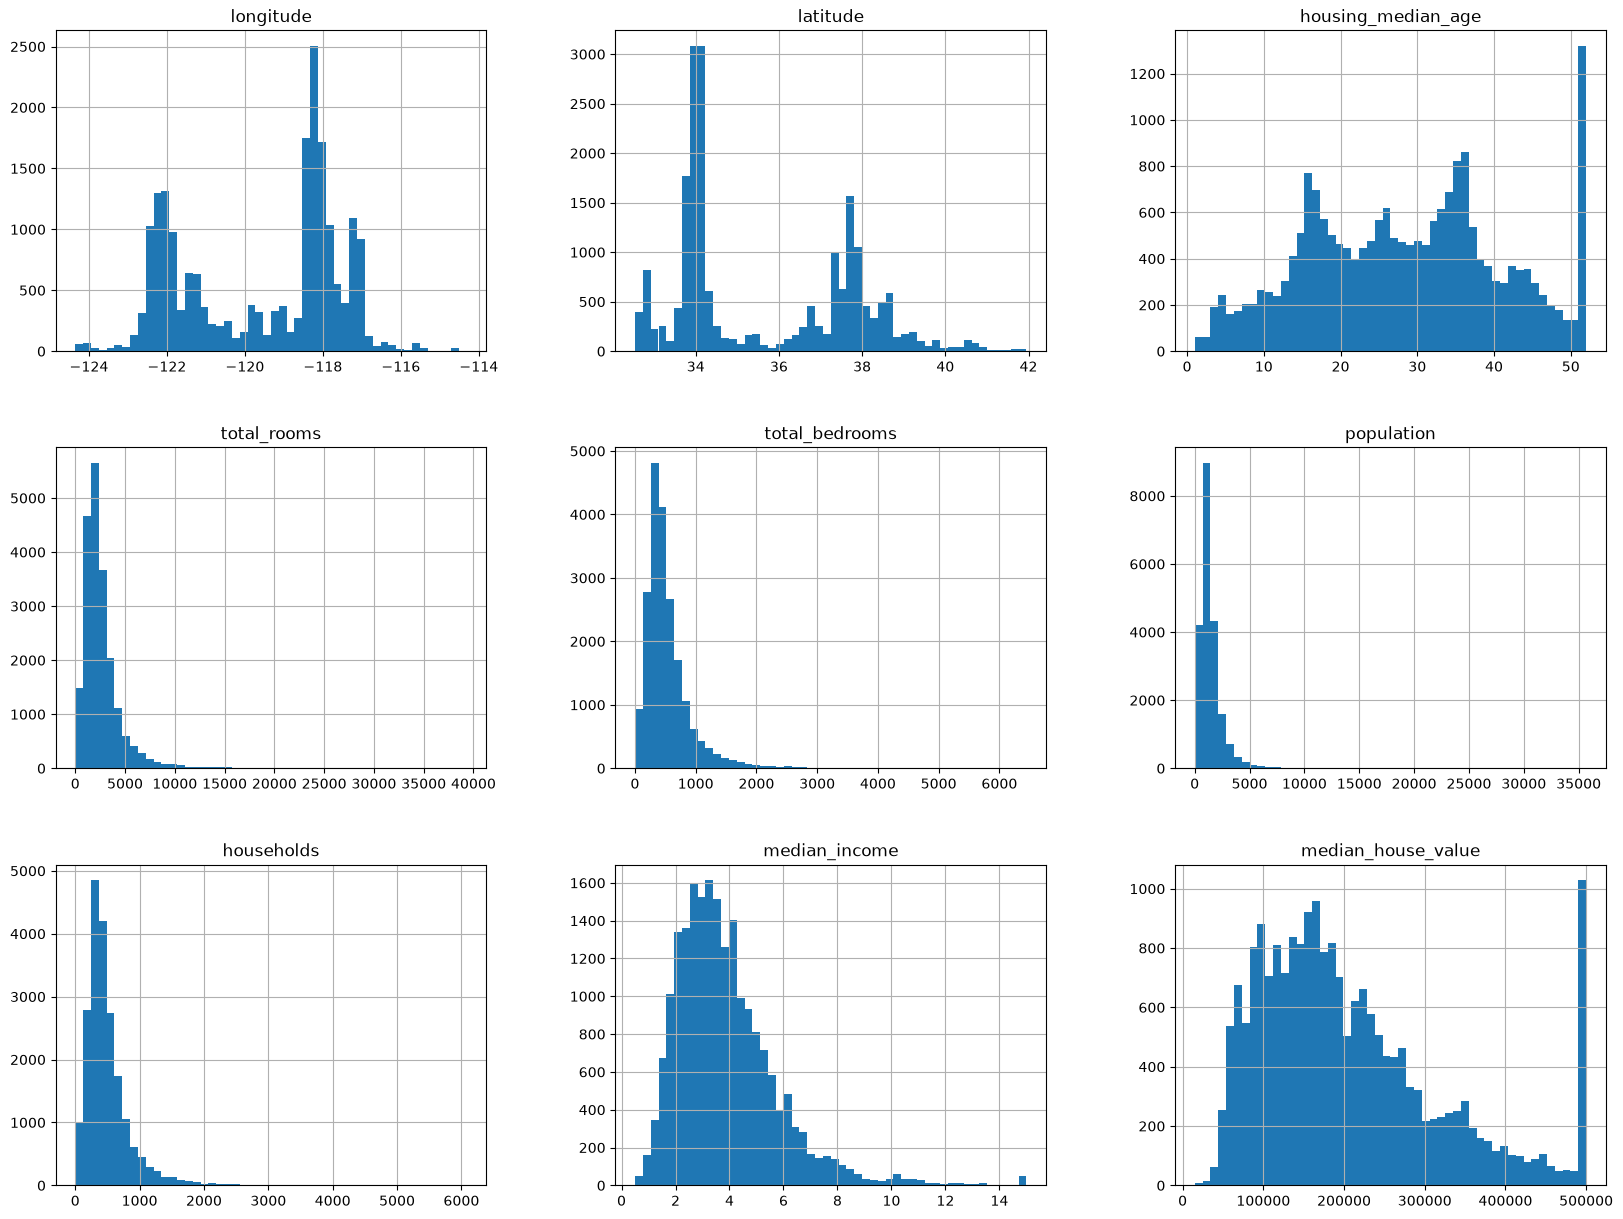

In [6]:
import matplotlib.pyplot as plt

# Set up matplotlib to plot directly in the notebook
%matplotlib inline

# Plot histograms for all numerical attributes
housing.hist(bins=50, figsize=(20, 15))

# Display the plots neatly
plt.show()

In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit

# 1. Create an income category attribute with 5 strata
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6.0, np.inf],
                               labels=[1, 2, 3, 4, 5])

# 2. Perform the stratified split and explicitly make COPIES
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    # Adding .copy() completely eliminates the warning
    strat_train_set = housing.iloc[train_index].copy()
    strat_test_set = housing.iloc[test_index].copy()

# 3. Drop the temporary income_cat column safely
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [11]:
housing = strat_train_set.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

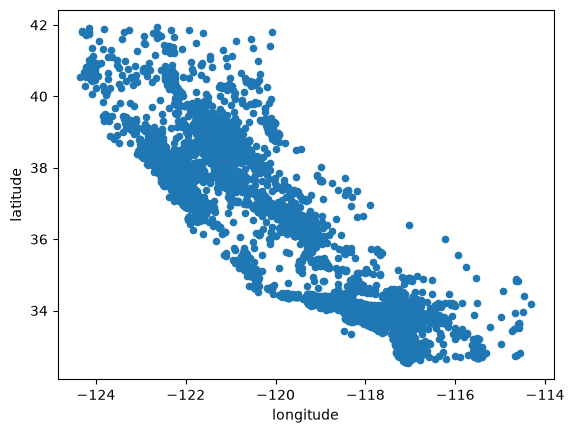

In [12]:
housing.plot(kind="scatter", x="longitude", y="latitude")

<Axes: xlabel='longitude', ylabel='latitude'>

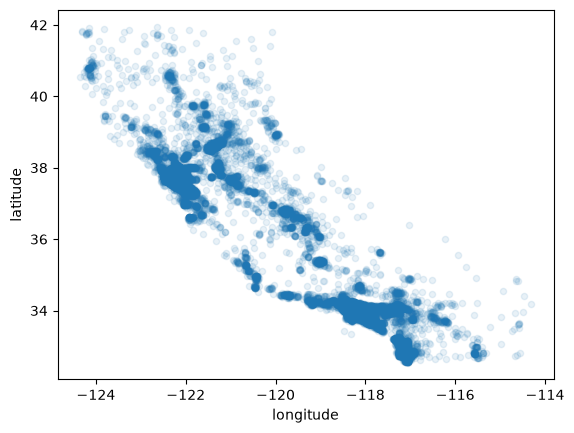

In [14]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

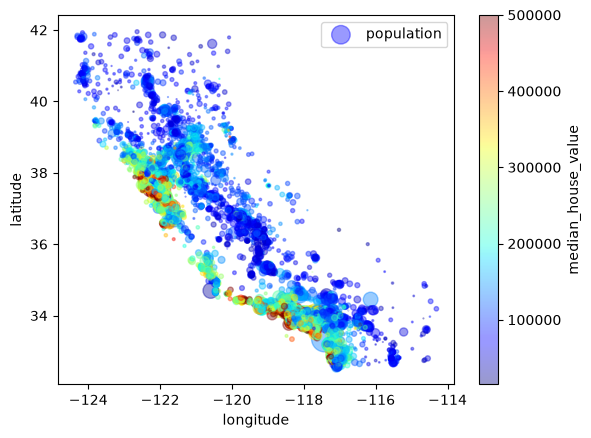

In [15]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s=housing["population"]/100, label="population",
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
)
plt.legend()

In [20]:
# Select only columns that contain numbers
numerical_housing = housing.select_dtypes(include=['number'])

# Calculate the correlation matrix on numerical data
corr_matrix = numerical_housing.corr()

# Sort the values relative to the median house value
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

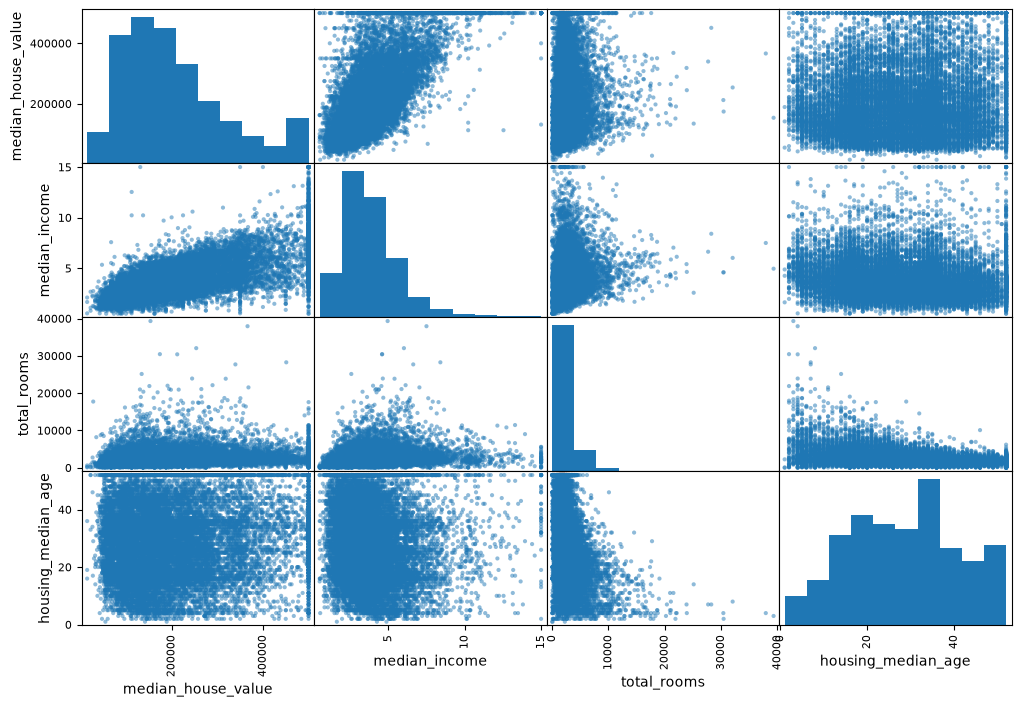

In [23]:
# The updated import path for modern Pandas
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]

# Using your numerical_housing DataFrame
scatter_matrix(numerical_housing[attributes], figsize=(12, 8))

<Axes: xlabel='median_income', ylabel='median_house_value'>

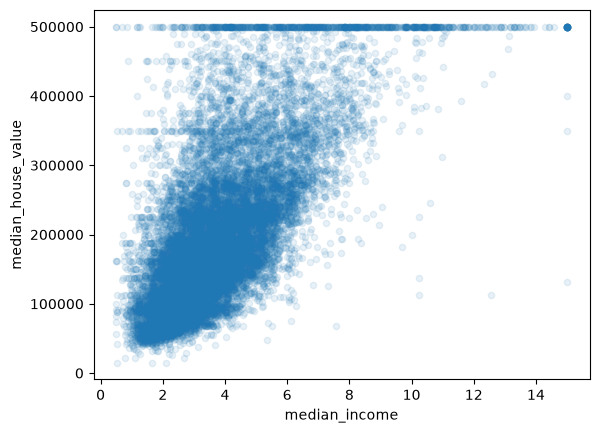

In [24]:
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1)

In [26]:
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"] = housing["population"] / housing["households"]

# 1. Select only numerical columns
numerical_housing = housing.select_dtypes(include=['number'])

# 2. Calculate the correlation matrix
corr_matrix = numerical_housing.corr()

# 3. Sort the values relative to the median house value
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64

In [27]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [30]:
from sklearn.impute import SimpleImputer

# 1. Initialize the imputer to use the median strategy
imputer = SimpleImputer(strategy="median")

# 2. Imputer only works on numerical data, so drop the text column 'ocean_proximity'
housing_num = housing.select_dtypes(include=['number'])

# 3. Fit the imputer to the data (this calculates the median for each column)
imputer.fit(housing_num)

# 4. Transform the dataset by replacing missing values with the calculated medians
X = imputer.transform(housing_num)

# 5. Convert the resulting NumPy array back into a clean Pandas DataFrame
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing.index)

In [32]:
from sklearn.preprocessing import OneHotEncoder

# 1. Isolate the categorical column
housing_cat = housing[["ocean_proximity"]]

# 2. Initialize the OneHotEncoder
cat_encoder = OneHotEncoder()

# 3. Fit and transform the text categories into a sparse matrix of 1s and 0s
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

# Optional: To view it as a dense array instead of a sparse matrix, use .toarray()
housing_cat_1hot.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]], shape=(16512, 5))

In [33]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

# Get column indices dynamically based on the original DataFrame structure
# This prevents hardcoding index numbers which easily break
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):
        """Initializes the transformer. 
        We include a hyperparameter toggle so we can easily test 
        if adding 'bedrooms_per_room' actually improves our ML model later."""
        self.add_bedrooms_per_room = add_bedrooms_per_room
        
    def fit(self, X, y=None):
        return self  # Nothing to calculate or learn here; just return self
        
    def transform(self, X):
        """Performs the array operations to calculate the new ratios."""
        # Calculate rooms per household and population per household
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        
        # Check our hyperparameter toggle
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

# --- How to use it ---
# Initialize the transformer
attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=True)

# Transform your numerical housing array (housing.values)
housing_extra_attribs = attr_adder.transform(housing.values)

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# 1. Separate column names by type
housing_num = housing.select_dtypes(include=['number'])
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

# 2. Build the sequential pipeline for numerical data
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('attribs_adder', CombinedAttributesAdder()),
    ('std_scaler', StandardScaler()),  # Feature Scaling (Standardization)
])

# 3. Combine both numerical and categorical pipelines
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

# 4. Run the full pipeline on your raw training data!
housing_prepared = full_pipeline.fit_transform(housing)

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Initialize and Train the model
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

# 2. Evaluate its performance on the entire training set
housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)

print(f"Linear Regression RMSE: ${lin_rmse:,.2f}")

Linear Regression RMSE: $68,627.87


In [36]:
from sklearn.tree import DecisionTreeRegressor

# 1. Initialize and Train the model
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_prepared, housing_labels)

# 2. Evaluate its performance
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)

print(f"Decision Tree RMSE: ${tree_rmse:,.2f}")

Decision Tree RMSE: $0.00


In [37]:
from sklearn.model_selection import cross_val_score

def display_scores(scores):
    print("Scores:", [f"${score:,.2f}" for score in scores])
    print(f"Mean Score: ${scores.mean():,.2f}")
    print(f"Standard Deviation: ${scores.std():,.2f}")

# 1. Evaluate Decision Tree with 10-fold cross-validation
# (Note: utility functions expect fitness scoring, so MSE is negative)
tree_scores = cross_val_score(tree_reg, housing_prepared, housing_labels,
                              scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-tree_scores)

print("--- Decision Tree Cross-Validation ---")
display_scores(tree_rmse_scores)

# 2. Evaluate Linear Regression with the same 10 folds
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels,
                             scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)

print("\n--- Linear Regression Cross-Validation ---")
display_scores(lin_rmse_scores)

--- Decision Tree Cross-Validation ---
Scores: ['$72,831.46', '$69,973.18', '$69,528.57', '$72,517.78', '$69,145.50', '$79,094.74', '$68,960.05', '$73,344.50', '$69,826.02', '$71,077.10']
Mean Score: $71,629.89
Standard Deviation: $2,914.04

--- Linear Regression Cross-Validation ---
Scores: ['$71,762.76', '$64,114.99', '$67,771.17', '$68,635.19', '$66,846.14', '$72,528.04', '$73,997.08', '$68,802.34', '$66,443.29', '$70,139.80']
Mean Score: $69,104.08
Standard Deviation: $2,880.33


In [38]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize and Train the Ensemble model
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(housing_prepared, housing_labels)

# 2. Evaluate its base performance on the training set
forest_predictions = forest_reg.predict(housing_prepared)
forest_mse = mean_squared_error(housing_labels, forest_predictions)
forest_rmse = np.sqrt(forest_mse)
print(f"Random Forest Training RMSE: ${forest_rmse:,.2f}")

# 3. Cross-validate the Random Forest
forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels,
                                scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)

print("\n--- Random Forest Cross-Validation ---")
display_scores(forest_rmse_scores)

Random Forest Training RMSE: $18,650.70

--- Random Forest Cross-Validation ---
Scores: ['$51,559.63', '$48,737.57', '$47,210.51', '$51,875.21', '$47,577.50', '$51,863.27', '$52,746.35', '$50,065.18', '$48,664.67', '$54,055.91']
Mean Score: $50,435.58
Standard Deviation: $2,203.34


In [39]:
import joblib
import os

# Define the target directory for saving models
MODEL_PATH = os.path.join("models")
os.makedirs(MODEL_PATH, exist_ok=True)

# 1. Save your models to files
joblib.dump(lin_reg, os.path.join(MODEL_PATH, "linear_regression_model.pkl"))
joblib.dump(tree_reg, os.path.join(MODEL_PATH, "decision_tree_model.pkl"))
joblib.dump(forest_reg, os.path.join(MODEL_PATH, "random_forest_model.pkl"))

print("All models successfully saved to the 'models/' directory!")

All models successfully saved to the 'models/' directory!


In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = [
    # Try 12 (3×4) combinations of hyperparameters
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    # Then try 6 (2×3) combinations with bootstrap set to False
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
]

forest_reg = RandomForestRegressor(random_state=42)

# Train across 5 folds, giving a total of (12+6)*5 = 90 rounds of training 
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(housing_prepared, housing_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` w

In [41]:
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Estimator Object:", grid_search.best_estimator_)

Best Hyperparameters: {'max_features': 8, 'n_estimators': 30}
Best Estimator Object: RandomForestRegressor(max_features=8, n_estimators=30, random_state=42)


In [42]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
        'n_estimators': randint(low=1, high=200),
        'max_features': randint(low=1, high=8),
    }

forest_reg = RandomForestRegressor(random_state=42)
rnd_search = RandomizedSearchCV(forest_reg, param_distributions=param_distribs,
                                n_iter=10, cv=5, scoring='neg_mean_squared_error', 
                                random_state=42)
rnd_search.fit(housing_prepared, housing_labels)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_features': <scipy.stats....001CF2FB59640>, 'n_estimators': <scipy.stats....001CF31D4E330>}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric 

In [43]:
import numpy as np

# 1. Get feature importances from the best model found by grid search
feature_importances = grid_search.best_estimator_.feature_importances_

# 2. Reconstruct the full list of attribute names to map them to importances
extra_attribs = ["rooms_per_hhold", "pop_per_hhold", "bedrooms_per_room"]
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attribs + extra_attribs + cat_one_hot_attribs

# 3. Sort and display feature importance alongside their labels
sorted_features = sorted(zip(feature_importances, attributes), reverse=True)
for importance, score in sorted_features:
    print(f"{importance:.4f} -> {score}")

0.3790 -> median_income
0.1657 -> INLAND
0.1070 -> pop_per_hhold
0.0697 -> longitude
0.0604 -> latitude
0.0548 -> rooms_per_hhold
0.0482 -> bedrooms_per_room
0.0422 -> housing_median_age
0.0158 -> population
0.0156 -> total_bedrooms
0.0152 -> total_rooms
0.0149 -> households
0.0068 -> <1H OCEAN
0.0030 -> NEAR OCEAN
0.0015 -> NEAR BAY
0.0001 -> ISLAND


In [44]:
cv_res = grid_search.cv_results_
for mean_score, params in zip(cv_res["mean_test_score"], cv_res["params"]):
    print(f"RMSE: ${np.sqrt(-mean_score):,.2f} | Params: {params}")

RMSE: $63,895.16 | Params: {'max_features': 2, 'n_estimators': 3}
RMSE: $54,916.32 | Params: {'max_features': 2, 'n_estimators': 10}
RMSE: $52,885.87 | Params: {'max_features': 2, 'n_estimators': 30}
RMSE: $60,075.37 | Params: {'max_features': 4, 'n_estimators': 3}
RMSE: $52,495.01 | Params: {'max_features': 4, 'n_estimators': 10}
RMSE: $50,187.24 | Params: {'max_features': 4, 'n_estimators': 30}
RMSE: $58,064.74 | Params: {'max_features': 6, 'n_estimators': 3}
RMSE: $51,519.32 | Params: {'max_features': 6, 'n_estimators': 10}
RMSE: $49,969.80 | Params: {'max_features': 6, 'n_estimators': 30}
RMSE: $58,895.82 | Params: {'max_features': 8, 'n_estimators': 3}
RMSE: $52,459.80 | Params: {'max_features': 8, 'n_estimators': 10}
RMSE: $49,898.99 | Params: {'max_features': 8, 'n_estimators': 30}
RMSE: $62,381.77 | Params: {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
RMSE: $54,476.57 | Params: {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
RMSE: $59,974.60 | Params: 

In [45]:
# 1. Isolate predictors and target labels from the test set
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

# 2. Pass raw test data through the established data preparation pipeline
X_test_prepared = full_pipeline.transform(X_test)

# 3. Predict using your absolute best model
final_model = grid_search.best_estimator_
final_predictions = final_model.predict(X_test_prepared)

# 4. Compute the final performance metric
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
print(f"Final Generalization RMSE on Test Set: ${final_rmse:,.2f}")

Final Generalization RMSE on Test Set: $47,873.26


In [46]:
from scipy import stats

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
confidence_interval = np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
                                                loc=squared_errors.mean(),
                                                scale=stats.sem(squared_errors)))

print(f"95% Confidence Interval: ${confidence_interval[0]:,.2f} to ${confidence_interval[1]:,.2f}")

95% Confidence Interval: $45,893.36 to $49,774.47
